## Loan Approval Prediction

In [2]:
#Fundamental ML Libraries

import pandas as pd #Data Processing
import numpy as np #Numerical Computation 
import matplotlib.pyplot as plt #Visualisation
import seaborn as sns #Visualisation

## Data Importation

In [3]:
loan_data = pd.read_csv('../data/loan.csv')

## Data Overview

In [4]:
loan_data.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [5]:
loan_data.tail(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
604,LP002959,Female,Yes,1,Graduate,No,12000,0.0,496.0,360.0,1.0,Semiurban,Y
605,LP002960,Male,Yes,0,Not Graduate,No,2400,3800.0,NaN,180.0,1.0,Urban,N
606,LP002961,Male,Yes,1,Graduate,No,3400,2500.0,173.0,360.0,1.0,Semiurban,Y
607,LP002964,Male,Yes,2,Not Graduate,No,3987,1411.0,157.0,360.0,1.0,Rural,Y
608,LP002974,Male,Yes,0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Y
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


## Observations

In [6]:
rows = loan_data.shape 
print(rows)
print(type(rows))

rows = loan_data.shape[0]
columns = loan_data.shape[1]

print(f'The number of rows in the data is {rows} and the number of columns is {columns}')

(614, 13)
<class 'tuple'>
The number of rows in the data is 614 and the number of columns is 13


In [7]:
loan_data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [8]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [9]:
loan_data['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [10]:
loan_data['Loan_Status'] = loan_data['Loan_Status'].map({'N':0, 'Y':1})

In [11]:
loan_data['Loan_Status'].value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

## Data Cleaning

In [12]:
loan_data.isnull().sum().sum()

np.int64(149)

In [13]:
categorical_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed',
    'Loan_Amount_Term',
    'Credit_History'
]

for col in categorical_cols:
    loan_data[col] = loan_data[col].fillna(loan_data[col].mode()[0])

In [14]:
loan_data['LoanAmount'] = loan_data['LoanAmount'].fillna(loan_data['LoanAmount'].median())

In [15]:
loan_data.isnull().sum().sum()

np.int64(0)

In [16]:
loan_data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,1
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,1
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,1
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,1


In [17]:
loan_data.duplicated().sum().sum()

np.int64(0)

In [18]:
loan_data.drop('Loan_ID', axis=1, inplace=True)

In [19]:
loan_data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,1
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,1
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,1
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,1


In [20]:
for col in loan_data.columns:
    print(col)
    print(loan_data[col].unique())
    print("-"*40)

Gender
['Male' 'Female']
----------------------------------------
Married
['No' 'Yes']
----------------------------------------
Dependents
['0' '1' '2' '3+']
----------------------------------------
Education
['Graduate' 'Not Graduate']
----------------------------------------
Self_Employed
['No' 'Yes']
----------------------------------------
ApplicantIncome
[ 5849  4583  3000  2583  6000  5417  2333  3036  4006 12841  3200  2500
  3073  1853  1299  4950  3596  3510  4887  2600  7660  5955  3365  3717
  9560  2799  4226  1442  3750  4166  3167  4692  3500 12500  2275  1828
  3667  3748  3600  1800  2400  3941  4695  3410  5649  5821  2645  4000
  1928  3086  4230  4616 11500  2708  2132  3366  8080  3357  3029  2609
  4945  5726 10750  7100  4300  3208  1875  4755  5266  1000  3333  3846
  2395  1378  3988  2366  8566  5695  2958  6250  3273  4133  3620  6782
  2484  1977  4188  1759  4288  4843 13650  4652  3816  3052 11417  7333
  3800  2071  5316  2929  3572  7451  5050 14583  2214

In [21]:
loan_data["Loan_Status"].value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

In [22]:
loan_data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,0.855049,0.687296
std,6109.041673,2926.248369,84.107233,64.428629,0.352339,0.463973
min,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000,0.000000
50%,3812.500000,1188.500000,128.000000,360.000000,1.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000,1.000000


## EDA

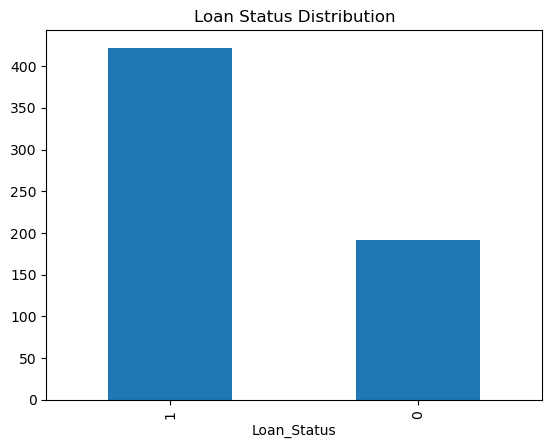

In [23]:
loan_data["Loan_Status"].value_counts().plot(kind="bar")
plt.title("Loan Status Distribution")
plt.show()

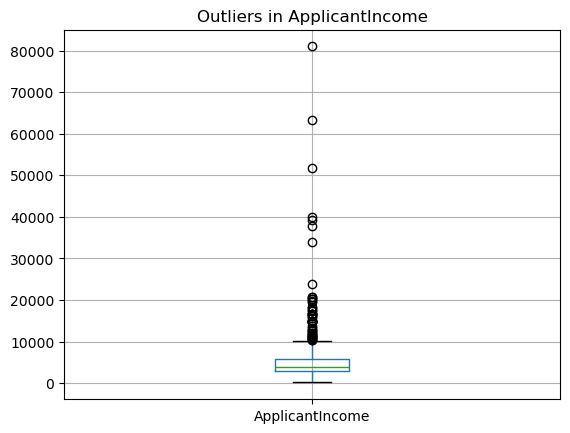

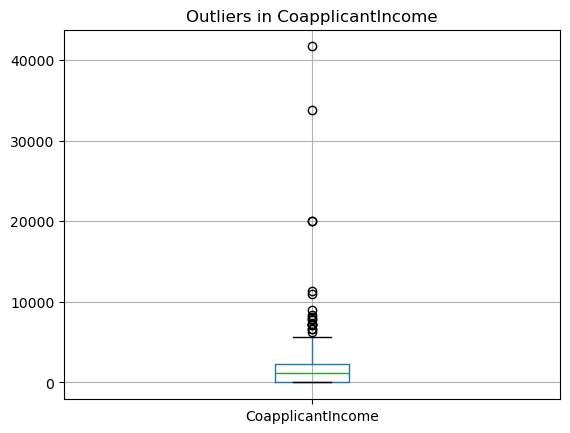

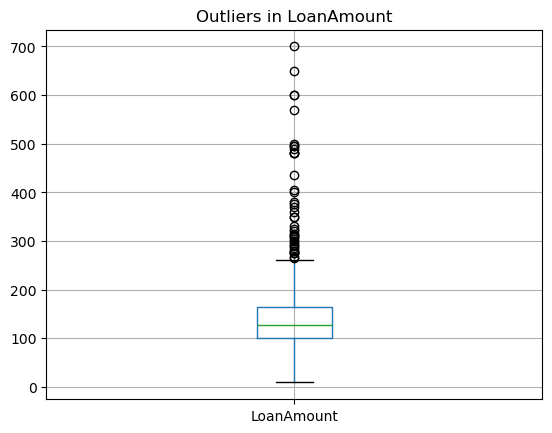

In [24]:
loan_data.boxplot(column = 'ApplicantIncome')
plt.title('Outliers in ApplicantIncome')
plt.show()
loan_data.boxplot(column = 'CoapplicantIncome')
plt.title('Outliers in CoapplicantIncome')
plt.show()
loan_data.boxplot(column = 'LoanAmount')
plt.title('Outliers in LoanAmount')
plt.show()

## Modeling

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [26]:
x = loan_data.drop("Loan_Status", axis=1)
y = loan_data["Loan_Status"]

In [27]:
numeric_cols = x.select_dtypes(include = ['number']).columns.tolist()
categorical_cols = x.select_dtypes(include = ['object']).columns.tolist()

In [28]:
numeric_cols

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History']

In [29]:
categorical_cols

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area']

## Pipeline

In [30]:
numeric_pipeline = Pipeline(steps = [('numericPipeline', StandardScaler())])
categorical_pipeline = Pipeline(steps = [('categoricalPipeline', OneHotEncoder(handle_unknown = 'ignore'))]) 

In [31]:
from sklearn.compose import ColumnTransformer

In [32]:
#Preprocessing pipeline
ml_preprocess = ColumnTransformer(

    transformers = [

        ('TransformNumeric', numeric_pipeline, numeric_cols),
        ('TransformCategory', categorical_pipeline, categorical_cols),
        
    ])

        
        

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [36]:
lr_model = Pipeline(steps=[
    ('preprocess', ml_preprocess),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

In [37]:
dt_model = Pipeline(steps=[
    ('preprocess', ml_preprocess),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

In [38]:
rf_model = Pipeline(steps=[
    ('preprocess', ml_preprocess),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [39]:
nb_model = Pipeline(steps=[
    ('preprocess', ml_preprocess),
    ('classifier', GaussianNB())
])

In [40]:
knn_model = Pipeline(steps=[
    ('preprocess', ml_preprocess),
    ('classifier', KNeighborsClassifier())
])

In [41]:
svm_model = Pipeline(steps=[
    ('preprocess', ml_preprocess),
    ('classifier', SVC(probability=True, random_state=42))
])

In [42]:
models = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'Naive Bayes': nb_model,
    'KNN': knn_model,
    'SVM': svm_model
}

## Training the models

In [43]:
for name, model in models.items():
    model.fit(x_train, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Naive Bayes trained successfully.
KNN trained successfully.
SVM trained successfully.


In [44]:
#lr_values = lr_model.predict(x_test)

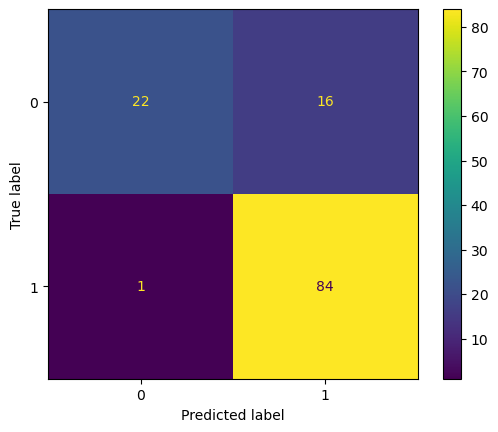

In [48]:
#ConfusionMatrixDisplay.from_predictions(y_test, lr_values)

In [49]:
lr_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [50]:
dt_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
rf_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [52]:
nb_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [53]:
knn_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [54]:
svm_model.fit(x_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('TransformNumeric', ...), ('TransformCategory', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Testing the models

In [49]:
lr_y = lr_model.predict(x_test)
dt_y = dt_model.predict(x_test)
rf_y = rf_model.predict(x_test)
nb_y = nb_model.predict(x_test)
knn_y = knn_model.predict(x_test)
svm_y = svm_model.predict(x_test)

In [50]:
lr_y

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0])

In [57]:
#lr_y = (lr_y >= 0.5).astype(int)
#dt_y = (dt_y >= 0.5).astype(int)
#rf_y = (rf_y >= 0.5).astype(int)
#nb_y = (nb_y >= 0.5).astype(int)
#knn_y = (knn_y >= 0.5).astype(int)
#svm_y = (svm_y >= 0.5).astype(int)

## Performance Evaluation

In [51]:
y_test.value_counts()

Loan_Status
1    85
0    38
Name: count, dtype: int64

In [66]:
results = []

for name, model in models.items():

    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

    print("=" * 60)
    print(name)
    print("=" * 60)
    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123

Decision Tree
              precision    recall  f1-score   support

           0       0.61      0.61      0.61        38
           1       0.82      0.82      0.82        85

    accuracy                           0.76       123
   macro avg       0.71      0.71      0.71       123
weighted avg       0.76      0.76      0.76       123

Random Forest
              precision    recall  f1-score   support

           0       0.75      0.63      0.69        38
           1       0.85      0.91      0.88        85

    accuracy                           0.82       123
   macro avg       0.80      0.77      0.78       123
weighted avg       0.82   

In [67]:
results_df = pd.DataFrame(results)

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
4,KNN,0.869919,0.848485,0.988235,0.913043
0,Logistic Regression,0.861789,0.840000,0.988235,0.908108
5,SVM,0.853659,0.831683,0.988235,0.903226
3,Naive Bayes,0.845528,0.836735,0.964706,0.896175
2,Random Forest,0.821138,0.846154,0.905882,0.875000
1,Decision Tree,0.756098,0.823529,0.823529,0.823529


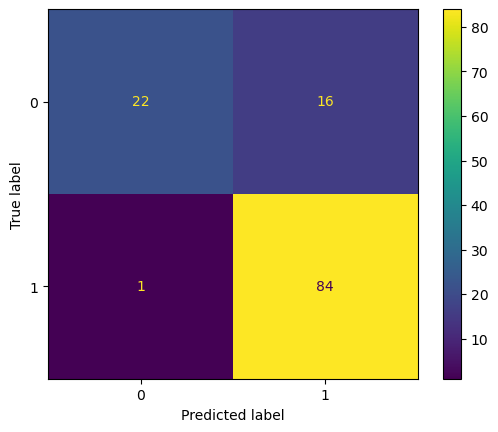

In [68]:
ConfusionMatrixDisplay.from_predictions(y_test, lr_y)
plt.show()

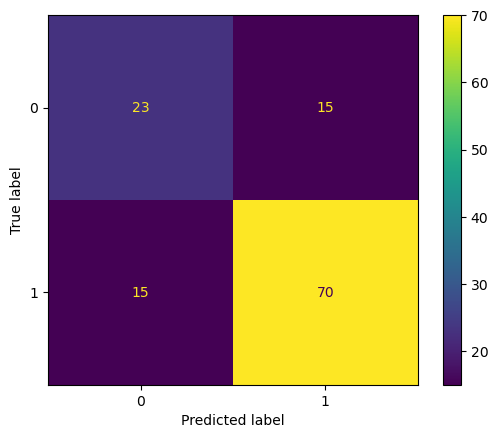

In [69]:
ConfusionMatrixDisplay.from_predictions(y_test, dt_y)
plt.show()

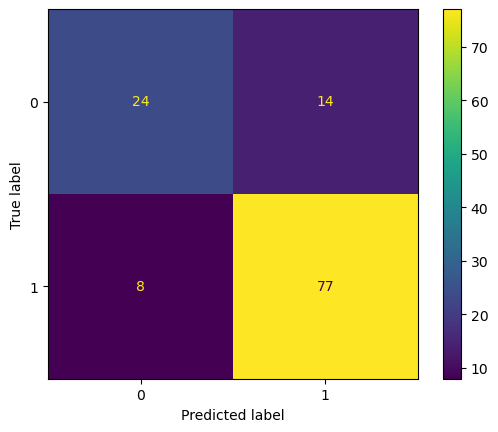

In [70]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_y)
plt.show()

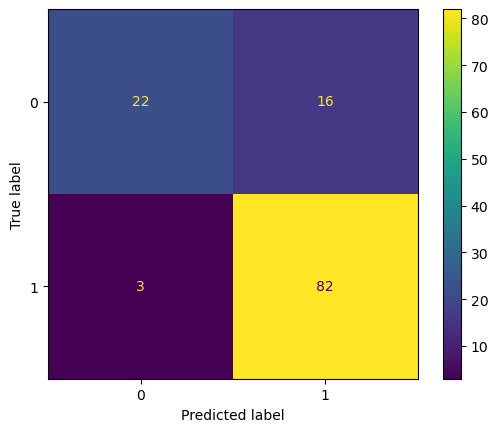

In [71]:
ConfusionMatrixDisplay.from_predictions(y_test, nb_y)
plt.show()

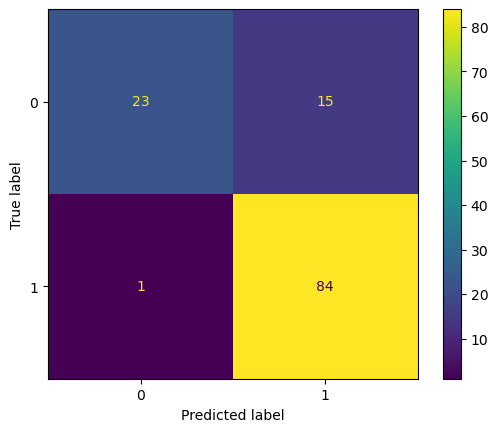

In [72]:
ConfusionMatrixDisplay.from_predictions(y_test, knn_y)
plt.show()

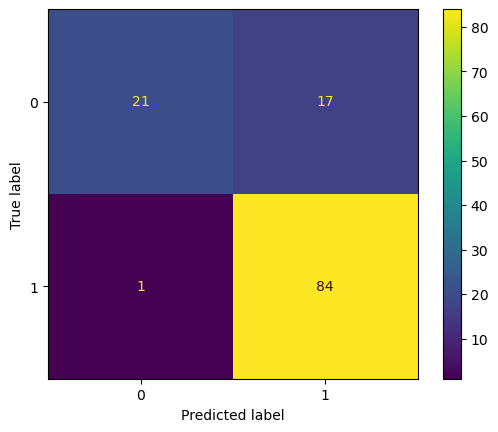

In [73]:
ConfusionMatrixDisplay.from_predictions(y_test, svm_y)
plt.show()

In [74]:
best_model = results_df.sort_values(
    by='Accuracy',
    ascending=False
).iloc[0]

print(best_model)

Model             KNN
Accuracy     0.869919
Precision    0.848485
Recall       0.988235
F1 Score     0.913043
Name: 4, dtype: object


In [94]:
import joblib

joblib.dump(knn_model, "../Model/loan_approval_pipeline.pkl")

['../Model/loan_approval_pipeline.pkl']

In [96]:
pipeline = joblib.load("../Model/loan_approval_pipeline.pkl")